In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.transform import resize

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [10]:
df = pd.read_pickle("../data/LSWMD.pkl")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (811457, 6)


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [11]:
df["failureLabel"] = df["failureType"].apply(lambda x: x[0][0])

print(df["failureLabel"].value_counts())

df.head()

IndexError: index 0 is out of bounds for axis 0 with size 0

In [12]:
print(df["failureType"].head(10))

0    [[none]]
1    [[none]]
2    [[none]]
3    [[none]]
4    [[none]]
5    [[none]]
6    [[none]]
7    [[none]]
8    [[none]]
9    [[none]]
Name: failureType, dtype: object


In [13]:
print(type(df["failureType"].iloc[0]))
print(df["failureType"].iloc[0])

<class 'numpy.ndarray'>
[['none']]


In [14]:
print(df["failureType"].iloc[100])
print(df["failureType"].iloc[1000])

[['Edge-Ring']]
[['none']]


In [15]:
def get_failure_label(x):
    if len(x) == 0:
        return "unknown"
    return x[0][0]

df["failureLabel"] = df["failureType"].apply(get_failure_label)

print(df["failureLabel"].value_counts())

failureLabel
unknown      638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [16]:
print(df[df["failureLabel"] == "unknown"].shape)

(638507, 7)


In [17]:
df_labeled = df[df["failureType"].apply(lambda x: len(x) > 0)].copy()

print("Labeled dataset shape:", df_labeled.shape)

Labeled dataset shape: (172950, 7)


In [18]:
df_labeled["failureLabel"] = df_labeled["failureType"].apply(lambda x: x[0][0])

print(df_labeled["failureLabel"].value_counts())

failureLabel
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [19]:
# Keep only defective wafers
df_defects = df_labeled[df_labeled["failureLabel"] != "none"].copy()

print(df_defects.shape)

print(df_defects["failureLabel"].value_counts())

(25519, 7)
failureLabel
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64


In [20]:
from skimage.transform import resize
import numpy as np

X = []

for wafer in df_defects["waferMap"]:
    wafer = resize(
    wafer,
    (32,32),
    anti_aliasing=False,
    preserve_range=True
)

X = np.array(X)

print("Shape:", X.shape)

Shape: (0,)


In [21]:
X = X.reshape(-1, 32, 32, 1)

print("CNN Input Shape:", X.shape)

CNN Input Shape: (0, 32, 32, 1)


In [22]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df_defects["failureLabel"])

print("Classes:")

for i, label in enumerate(encoder.classes_):
    print(i, "->", label)

Classes:
0 -> Center
1 -> Donut
2 -> Edge-Loc
3 -> Edge-Ring
4 -> Loc
5 -> Near-full
6 -> Random
7 -> Scratch


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

ValueError: Found input variables with inconsistent numbers of samples: [0, 25519]

In [24]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print(class_weights)

NameError: name 'y_train' is not defined

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Input
)

model = Sequential([

    Input(shape=(32,32,1)),

    # Block 1
    Conv2D(32, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 2
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    # Block 3
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(256, activation="relu"),
    Dropout(0.5),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(8, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,040 (2.49 MB)

 Trainable params: 651,592 (2.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [82]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN Compiled Successfully!")

CNN Compiled Successfully!


In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

NameError: name 'X_train' is not defined

In [27]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

NameError: name 'X_test' is not defined

In [28]:
print(np.unique(y_train))
print(np.unique(y_test))

NameError: name 'y_train' is not defined

In [29]:
print("Train Min :", X_train.min())
print("Train Max :", X_train.max())

print("Test Min :", X_test.min())
print("Test Max :", X_test.max())

NameError: name 'X_train' is not defined

In [30]:
print("Data Type:", X_train.dtype)

NameError: name 'X_train' is not defined

In [31]:
np.unique(X_train[0])

NameError: name 'X_train' is not defined

In [32]:
wafer = df_defects["waferMap"].iloc[0]

print(np.unique(wafer))
print("Min:", wafer.min())
print("Max:", wafer.max())

[0 1 2]
Min: 0
Max: 2


In [33]:
wafer_resized = resize(
    wafer,
    (32, 32),
    anti_aliasing=False
)

print(np.unique(wafer_resized))
print("Min:", wafer_resized.min())
print("Max:", wafer_resized.max())

[0.00000000e+00 1.53186275e-05 3.06372549e-05 6.12745098e-05
 7.65931373e-05 1.07230392e-04 1.99142157e-04 2.60416667e-04
 5.97426471e-04 6.28063725e-04 6.58700980e-04 6.89338235e-04
 7.96568627e-04 8.11887255e-04 9.80392157e-04 1.11825980e-03
 1.21017157e-03 1.24080882e-03 1.33272059e-03 1.39399510e-03
 1.62377451e-03 1.66973039e-03 1.79227941e-03 1.88419118e-03
 1.88419118e-03 2.22120098e-03 2.38970588e-03 2.52757353e-03
 2.75735294e-03 2.77267157e-03 2.78799020e-03 2.94117647e-03
 2.95649510e-03 3.20159314e-03 3.53860294e-03 3.56924020e-03
 3.59987745e-03 3.75306373e-03 3.82965686e-03 3.92156863e-03
 3.92156863e-03 3.92156863e-03 3.93688725e-03 3.96752451e-03
 4.02879902e-03 4.05943627e-03 4.05943627e-03 4.10539216e-03
 4.15134804e-03 4.21262255e-03 4.24325980e-03 4.27389706e-03
 4.36580882e-03 4.39644608e-03 4.42708333e-03 4.45772059e-03
 4.45772059e-03 4.48835784e-03 4.54963235e-03 4.56495098e-03
 4.58026961e-03 4.61090686e-03 4.61090686e-03 4.64154412e-03
 4.70281863e-03 4.733455

In [34]:
print(X.min())
print(X.max())
print(np.unique(X[0]))

ValueError: zero-size array to reduction operation minimum which has no identity

In [35]:
print(df_defects.shape)

(25519, 7)


In [36]:
print(df_defects.head())

                                             waferMap  dieSize lotName  \
19  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   1683.0    lot1   
36  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   2460.0    lot2   
37  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   2460.0    lot2   
38  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   2460.0    lot2   
39  [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...   2460.0    lot2   

    waferIndex trianTestLabel   failureType failureLabel  
19        20.0   [[Training]]       [[Loc]]          Loc  
36        12.0   [[Training]]  [[Edge-Loc]]     Edge-Loc  
37        13.0   [[Training]]  [[Edge-Loc]]     Edge-Loc  
38        14.0   [[Training]]  [[Edge-Loc]]     Edge-Loc  
39        15.0   [[Training]]  [[Edge-Loc]]     Edge-Loc  


In [37]:
print(len(df_defects["waferMap"]))

25519


In [38]:
from skimage.transform import resize
import numpy as np

X = []

for wafer in df_defects["waferMap"]:
    wafer = resize(
        wafer,
        (32,32),
        anti_aliasing=False,
        preserve_range=True
    )

    X.append(wafer)

X = np.array(X)

In [39]:
from skimage.transform import resize
import numpy as np

X = []

for wafer in df_defects["waferMap"]:
    wafer = resize(
        wafer,
        (32,32),
        anti_aliasing=False,
        preserve_range=True
    )

    X.append(wafer)

X = np.array(X)

print("Shape:", X.shape)

Shape: (25519, 32, 32)


In [40]:
X = X.reshape(-1, 32, 32, 1)

print("Shape:", X.shape)

Shape: (25519, 32, 32, 1)


In [41]:
print("Min:", X.min())
print("Max:", X.max())
print("Unique values in first wafer:")
print(np.unique(X[0]))

Min: 0.0
Max: 2.0
Unique values in first wafer:
[0.         0.00390625 0.0078125  0.015625   0.01953125 0.02734375
 0.05078125 0.06640625 0.15234375 0.16015625 0.16796875 0.17578125
 0.203125   0.20703125 0.25       0.28515625 0.30859375 0.31640625
 0.33984375 0.35546875 0.4140625  0.42578125 0.45703125 0.48046875
 0.56640625 0.609375   0.64453125 0.703125   0.70703125 0.7109375
 0.75       0.75390625 0.81640625 0.90234375 0.91015625 0.91796875
 0.95703125 0.9765625  1.         1.00390625 1.01171875 1.02734375
 1.03515625 1.046875   1.05859375 1.07421875 1.08203125 1.08984375
 1.11328125 1.12109375 1.12890625 1.13671875 1.14453125 1.16015625
 1.1640625  1.16796875 1.17578125 1.18359375 1.19921875 1.20703125
 1.21484375 1.22265625 1.23046875 1.2421875  1.24609375 1.25
 1.265625   1.26953125 1.2890625  1.29296875 1.30078125 1.328125
 1.36328125 1.38671875 1.41015625 1.43359375 1.453125   1.48046875
 1.50390625 1.515625   1.52734375 1.546875   1.55078125 1.57421875
 1.58984375 1.59765625 

In [42]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [43]:
print("X_train max:", X_train.max())
print("X_train min:", X_train.min())

print("X_test max:", X_test.max())
print("X_test min:", X_test.min())

NameError: name 'X_train' is not defined

In [44]:
X = X.reshape(-1, 32, 32, 1)

print(X.shape)

(25519, 32, 32, 1)


In [45]:
print(y_small_encoded.shape)

NameError: name 'y_small_encoded' is not defined

In [ ]:
%whos

Variable               Type             Data/Info
-------------------------------------------------
Adam                   type             <class 'keras.src.optimizers.adam.Adam'>
BatchNormalization     type             <class 'keras.src.layers.<...>tion.BatchNormalization'>
Conv2D                 type             <class 'keras.src.layers.<...>olutional.conv2d.Conv2D'>
Dense                  type             <class 'keras.src.layers.core.dense.Dense'>
Dropout                type             <class 'keras.src.layers.<...>ization.dropout.Dropout'>
EarlyStopping          type             <class 'keras.src.callbac<...>_stopping.EarlyStopping'>
Flatten                type             <class 'keras.src.layers.<...>shaping.flatten.Flatten'>
Input                  function         <function Input at 0x000002D3AB82F100>
LabelEncoder           type             <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
MaxPooling2D           type             <class 'keras.src.layers.<...>_pooling2d

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train max:", X_train.max())
print("X_test max :", X_test.max())

X_train max: 2.0
X_test max : 2.0


In [47]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(0.7429039301310044), 1: np.float64(5.747466216216216), 2: np.float64(0.6147615032522283), 3: np.float64(0.32952931301652894), 4: np.float64(0.8879175365344467), 5: np.float64(21.444327731092436), 6: np.float64(3.6823593073593073), 7: np.float64(2.6721204188481678)}


In [48]:
model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(8, activation='softmax'))

print("CNN Model Created Successfully!")

CNN Model Created Successfully!


c:\Users\hp\OneDrive\Documents\AI semiC detect defection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN Compiled Successfully!")

CNN Compiled Successfully!


In [50]:
print(X_train.max())
print(X_test.max())

2.0
2.0


In [51]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.5219 - loss: 1.4182 - val_accuracy: 0.7002 - val_loss: 0.8177
Epoch 2/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.7054 - loss: 0.7376 - val_accuracy: 0.7717 - val_loss: 0.5857
Epoch 3/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7304 - loss: 0.6715 - val_accuracy: 0.7633 - val_loss: 0.6079
Epoch 4/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.7514 - loss: 0.6322 - val_accuracy: 0.7547 - val_loss: 0.5711
Epoch 5/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.7598 - loss: 0.5704 - val_accuracy: 0.7641 - val_loss: 0.6505
Epoch 6/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7757 - loss: 0.5576 - val_accuracy: 0.7665 - val_loss: 0.5623
Epoch 7/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7796 - loss: 0.5288 - val_accuracy: 0.8041 - val_loss: 0.4929
Epoch 8/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.7994 - loss: 0.4831 - 

In [52]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8648 - loss: 0.3498
Test Accuracy: 0.864811897277832


In [53]:
model.save("wafer_defect_cnn.keras")

In [54]:
model.save("wafer_defect_cnn.keras")
print("Model saved successfully!")

Model saved successfully!


In [55]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,666 (3.60 MB)

 Trainable params: 314,888 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 629,778 (2.40 MB)

In [56]:
y_pred = model.predict(X_test)

160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [57]:
import numpy as np

y_pred_classes = np.argmax(y_pred, axis=1)

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)

print(cm)

[[ 836    4    1    0   14    0    2    2]
 [   1  104    0    0    6    0    0    0]
 [  13    1  818   46   53    3    6   98]
 [   2    2   85 1830    1    0    1   15]
 [  27   22   72    0  481    0    2  115]
 [   0    0    1    0    0   28    1    0]
 [   2    4    2    1   11    7  146    0]
 [   3    2   15    1   46    0    0  171]]


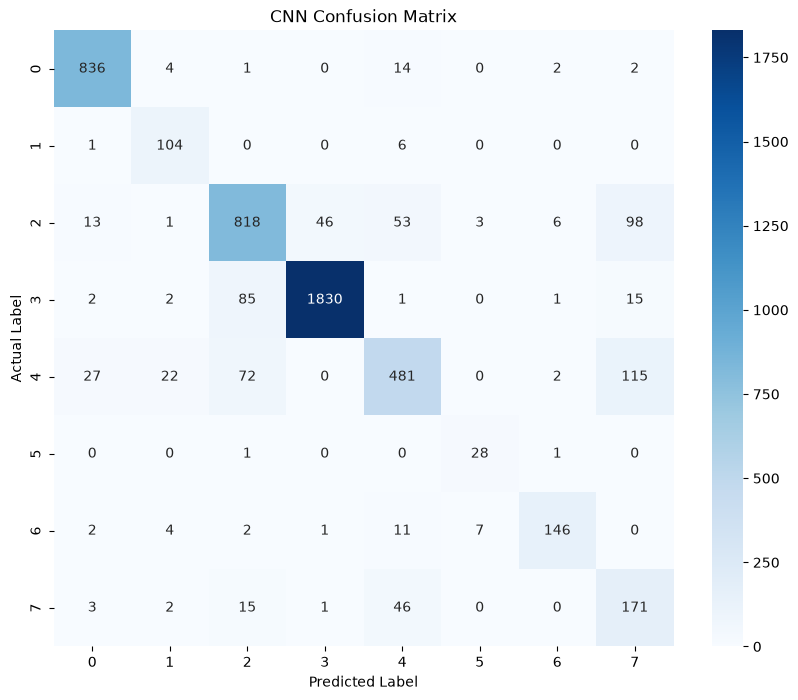

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("CNN Confusion Matrix")

plt.show()

In [60]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

      Center       0.95      0.97      0.96       859
       Donut       0.75      0.94      0.83       111
    Edge-Loc       0.82      0.79      0.81      1038
   Edge-Ring       0.97      0.95      0.96      1936
         Loc       0.79      0.67      0.72       719
   Near-full       0.74      0.93      0.82        30
      Random       0.92      0.84      0.88       173
     Scratch       0.43      0.72      0.54       238

    accuracy                           0.86      5104
   macro avg       0.80      0.85      0.81      5104
weighted avg       0.88      0.86      0.87      5104



In [61]:
model.save("models/wafer_defect_cnn.keras")
print("CNN model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'models/wafer_defect_cnn.keras'

In [62]:
model.save("models/wafer_defect_cnn.keras")
print("CNN model saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'models/wafer_defect_cnn.keras'

In [63]:
model.save("../models/wafer_defect_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [64]:
import joblib

joblib.dump(encoder, "../models/label_encoder.pkl")

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [65]:
import joblib

joblib.dump(encoder, "../models/label_encoder.pkl")

print("Label Encoder Saved!")

Label Encoder Saved!


In [66]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

y_pred = y_pred.argmax(axis=1)

print(classification_report(y_test, y_pred))

160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       859
           1       0.75      0.94      0.83       111
           2       0.82      0.79      0.81      1038
           3       0.97      0.95      0.96      1936
           4       0.79      0.67      0.72       719
           5       0.74      0.93      0.82        30
           6       0.92      0.84      0.88       173
           7       0.43      0.72      0.54       238

    accuracy                           0.86      5104
   macro avg       0.80      0.85      0.81      5104
weighted avg       0.88      0.86      0.87      5104



In [67]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 836    4    1    0   14    0    2    2]
 [   1  104    0    0    6    0    0    0]
 [  13    1  818   46   53    3    6   98]
 [   2    2   85 1830    1    0    1   15]
 [  27   22   72    0  481    0    2  115]
 [   0    0    1    0    0   28    1    0]
 [   2    4    2    1   11    7  146    0]
 [   3    2   15    1   46    0    0  171]]


In [68]:
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "../models/classification_report.csv"
)

In [69]:
import numpy as np

np.save(
    "../models/confusion_matrix.npy",
    cm
)

In [70]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [71]:
from tensorflow.keras.models import load_model

model = load_model("../models/wafer_defect_cnn.keras")

In [72]:
for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

conv2d_6 Conv2D
max_pooling2d_6 MaxPooling2D
conv2d_7 Conv2D
max_pooling2d_7 MaxPooling2D
flatten_2 Flatten
dense_6 Dense
dropout_4 Dropout
dense_7 Dense


In [73]:
print(model)

<Sequential name=sequential_2, built=True>


In [74]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,666 (3.60 MB)

 Trainable params: 314,888 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 629,778 (2.40 MB)

In [75]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>


In [76]:
print(model.inputs)
print(model.outputs)

[<KerasTensor shape=(None, 32, 32, 1), dtype=float32, sparse=False, ragged=False, name=input_layer_2>]
[<KerasTensor shape=(None, 8), dtype=float32, sparse=False, ragged=False, name=keras_tensor_140>]


In [77]:
from tensorflow.keras.models import load_model

model = load_model("../models/wafer_defect_cnn.keras")

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,666 (3.60 MB)

 Trainable params: 314,888 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 629,778 (2.40 MB)

In [78]:
print("Number of layers:", len(model.layers))

for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

Number of layers: 8
0 conv2d_6 Conv2D
1 max_pooling2d_6 MaxPooling2D
2 conv2d_7 Conv2D
3 max_pooling2d_7 MaxPooling2D
4 flatten_2 Flatten
5 dense_6 Dense
6 dropout_4 Dropout
7 dense_7 Dense


In [79]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [83]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 35s 52ms/step - accuracy: 0.8518 - loss: 0.3737 - val_accuracy: 0.8493 - val_loss: 0.3922
Epoch 2/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.8606 - loss: 0.3414 - val_accuracy: 0.8509 - val_loss: 0.3801
Epoch 3/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.8723 - loss: 0.2975 - val_accuracy: 0.8578 - val_loss: 0.3715
Epoch 4/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.8762 - loss: 0.2904 - val_accuracy: 0.8458 - val_loss: 0.4026
Epoch 5/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8823 - loss: 0.2670 - val_accuracy: 0.8679 - val_loss: 0.3546
Epoch 6/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8917 - loss: 0.2557 - val_accuracy: 0.8554 - val_loss: 0.3789
Epoch 7/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8870 - loss: 0.2598 - val_accuracy: 0.8752 - val_loss: 0.3516
Epoch 8/20
638/638 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.8871 - loss: 0.2628 - 

In [84]:
model.save("../models/wafer_defect_cnn.keras")

print("✅ Improved model saved successfully!")

✅ Improved model saved successfully!


In [1]:
from tensorflow.keras.models import load_model

test_model = load_model("../models/wafer_defect_cnn.keras")

print(type(test_model))
print()

print("Inputs:")
print(test_model.inputs)
print()

print("Outputs:")
try:
    print(test_model.outputs)
except Exception as e:
    print(e)

print()

print("Layers:")
for i, layer in enumerate(test_model.layers):
    print(i, layer.name, layer.__class__.__name__)

<class 'keras.src.models.sequential.Sequential'>

Inputs:
[<KerasTensor shape=(None, 32, 32, 1), dtype=float32, sparse=False, ragged=False, name=input_layer_2>]

Outputs:
[<KerasTensor shape=(None, 8), dtype=float32, sparse=False, ragged=False, name=keras_tensor_35>]

Layers:
0 conv2d_6 Conv2D
1 max_pooling2d_6 MaxPooling2D
2 conv2d_7 Conv2D
3 max_pooling2d_7 MaxPooling2D
4 flatten_2 Flatten
5 dense_6 Dense
6 dropout_4 Dropout
7 dense_7 Dense
